In [81]:
import scanpy as sc
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

from scipy.spatial import KDTree

from sklearn.metrics import accuracy_score, classification_report

import os
import json

# Load Data

In [82]:
downloads = os.path.expanduser('~') + '/Downloads/data/'

## Gene Expression Data

In [83]:
h5_filtered = f'{downloads}/CytAssist_11mm_FFPE_Human_Lung_Cancer_filtered_feature_bc_matrix.h5'

In [84]:
adata =  sc.read_10x_h5(h5_filtered)

/opt/homebrew/anaconda3/envs/jelly/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/homebrew/anaconda3/envs/jelly/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [85]:
adata.var_names_make_unique()

In [86]:
print(adata)

AnnData object with n_obs × n_vars = 6195 × 18085
    var: 'gene_ids', 'feature_types', 'genome'


In [87]:
# cell barcodes
adata.obs

""
AACAATCCGAGTGGAC-1
AACAATGGAACCACAT-1
AACACCAGCCTACTCG-1
AACACCATTCGCATAC-1
AACACCGAGCTTGGAT-1
...
TGTTGCTCGATGTCTG-1
TGTTGGTGAGCGGACG-1
TGTTGGTGCGCTTCGC-1
TGTTGGTGCGGAATCA-1


In [88]:
# gene variable data
adata.var.head()

,gene_ids,feature_types,genome
SAMD11,ENSG00000187634,Gene Expression,GRCh38
NOC2L,ENSG00000188976,Gene Expression,GRCh38
KLHL17,ENSG00000187961,Gene Expression,GRCh38
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38
PERM1,ENSG00000187642,Gene Expression,GRCh38


In [148]:
# gene expression profile for each single cell
sample_df = pd.DataFrame(adata.X.toarray()[:5], columns=adata.var.index)
sample_df

,SAMD11,NOC2L,KLHL17,PLEKHN1,PERM1,HES4,ISG15,AGRN,RNF223,C1orf159,...,MT-ND2,MT-CO2,MT-ATP6,MT-CO3,MT-ND3,MT-ND4L,MT-ND4,MT-ND5,MT-ND6,MT-CYB
0,0.083058,0.418466,0.0,0.000000,0.000000,0.297449,0.297449,0.623823,0.083058,0.083058,...,3.197444,4.590230,4.190264,5.190134,3.323628,4.045153,4.098299,2.727186,2.002663,4.183686
1,0.000000,0.190664,0.0,0.000000,0.000000,0.190664,0.350732,0.609881,0.000000,0.000000,...,3.350499,4.706352,4.543864,5.311485,3.952069,3.893903,4.452735,2.740431,1.988093,4.476905
2,0.000000,0.404252,0.0,0.153631,0.000000,0.153631,0.000000,0.000000,0.000000,0.153631,...,3.425071,4.680064,4.521801,5.240765,4.071127,3.846582,4.150075,2.966958,2.136852,4.318328
3,0.000000,0.684754,0.0,0.093789,0.179532,0.331685,0.000000,0.463715,0.000000,0.179532,...,3.634243,4.981820,4.685594,5.484879,4.029994,4.003428,4.412971,2.984708,2.287426,4.488680
4,0.275978,0.584752,0.0,0.000000,0.000000,0.147479,0.000000,0.492032,0.000000,0.000000,...,3.360692,4.778372,4.710648,5.375298,4.053031,3.722386,4.322403,3.075384,2.276242,4.497922


In [89]:
# gene expression matrix: gene expression values across all genes for cell at index 10
adata.X[10, :].toarray()

array([[  2.,   8.,   2., ..., 174.,  70., 772.]], dtype=float32)

In [90]:
# first 2 cells' gene expression values across all genes
print(f'first 2 cells\' data:\n{adata.X[:2].toarray()}\n')

print(f'length of 1 cell array:{len(adata.X[:2].toarray()[0])}')
print(f'number of genes: {adata.var.shape[0]}')

first 2 cells' data:
[[  1.   6.   0. ... 165.  74. 746.]
 [  0.   1.   0. ...  69.  30. 414.]]

length of 1 cell array:18085
number of genes: 18085


## Spatial Data

In [91]:
# spatial coordinate information of cells
spatial_data = f'{downloads}/spatial/tissue_positions.csv'

# coordinates scaling information
scaling_data = f'{downloads}/spatial/scalefactors_json.json'

In [92]:
with open(scaling_data) as f:
    scaling_factors = json.load(f)
    
scaling_factors

{'regist_target_img_scalef': 0.15580368,
 'tissue_hires_scalef': 0.051934563,
 'tissue_lowres_scalef': 0.015580369,
 'fiducial_diameter_fullres': 383.59472791732895,
 'spot_diameter_fullres': 219.1969873813308}

In [93]:
spatial_df = pd.read_csv(spatial_data)

# rename 10x Genomics column names for convenience
spatial_df.columns = ['barcode', 'in_tissue', 'x', 'y', 'image_x', 'image_y']

# multiply image_x, image_y coordinates by scaling factor
spatial_df['image_x'] = spatial_df['image_x'] * scaling_factors['tissue_hires_scalef']
spatial_df['image_y'] = spatial_df['image_y'] * scaling_factors['tissue_hires_scalef']

print(f'spatial_df shape: {spatial_df.shape}')

# select spots only in tissue
spatial_df = spatial_df[spatial_df['in_tissue'] == 1].reset_index(drop=True)
print(f'in_tissue only spatial_df shape: {spatial_df.shape}')

spatial_df shape: (14336, 6)
in_tissue only spatial_df shape: (6195, 6)


In [94]:
spatial_df.head()

,barcode,in_tissue,x,y,image_x,image_y
0,TGAGCTCCGTTGCTTC-1,1,10,32,1583.173218,353.155028
1,CTAAGTTCGGACGGCT-1,1,10,34,1583.380957,372.111144
2,GCCTTCGCTCAACCTG-1,1,10,36,1583.536760,391.119194
3,TGGTACTGCACTGTCG-1,1,10,38,1583.692564,410.075309
4,ATTAGTATCTATGAAG-1,1,11,13,1565.203860,173.045964


## Merge Gene Expression & Spatial Data

The adata object has its data in separated sections We will use the spatial data barcode as a key to build a coherent dataset.

In [95]:
tissue_img = plt.imread(f'{downloads}/spatial/tissue_hires_image.png')
tissue_img.shape

(1708, 2000, 3)

In [96]:
# add values from spatial_df 'x' column to adata that has matching 'barcode' index
adata.obs['x'] = spatial_df.set_index('barcode').loc[adata.obs_names, 'image_x']
adata.obs['y'] = spatial_df.set_index('barcode').loc[adata.obs_names, 'image_y']

adata.obs.head()

,x,y
AACAATCCGAGTGGAC-1,58.374449,509.478063
AACAATGGAACCACAT-1,861.075055,359.802652
AACACCAGCCTACTCG-1,1239.262542,422.747343
AACACCATTCGCATAC-1,886.938467,1374.655948
AACACCGAGCTTGGAT-1,827.577261,284.237863


## Add Tissue Labels For GCN Training

In [97]:
labels_df = pd.read_csv(f'{downloads}/clusters_2.csv')
labels_df.head()

,Barcode,Cluster
0,AACAATCCGAGTGGAC-1,1
1,AACAATGGAACCACAT-1,1
2,AACACCAGCCTACTCG-1,1
3,AACACCATTCGCATAC-1,1
4,AACACCGAGCTTGGAT-1,1


In [98]:
adata.obs['labels'] = labels_df.set_index('Barcode').loc[adata.obs_names, 'Cluster']

# labels are 1 and 2, but need to be 0 and 1
adata.obs['labels'] = adata.obs['labels'] - 1

In [99]:
adata.obs['labels'].value_counts()

labels
0    5632
1     563
Name: count, dtype: int64

## View Tissue Spots

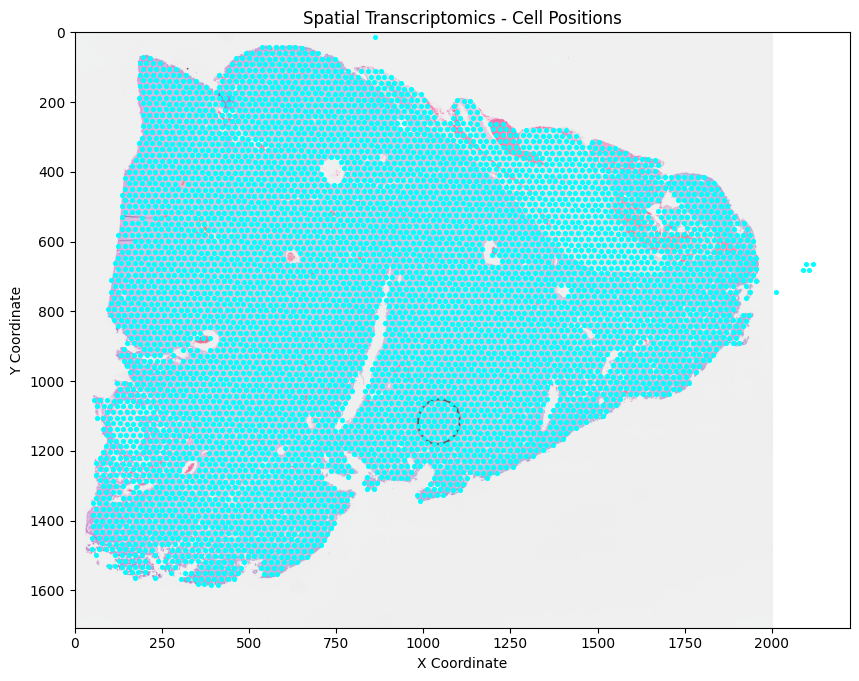

In [100]:
# visualize tissue image
plt.figure(figsize=(10, 10))
plt.imshow(tissue_img)

# plot tissue spots
# NOTE: we flipped coordinates to match traditional cartesian system
# 10x has y-coordinates in top left, and x-coordinates start in bottom left
plt.scatter(adata.obs['y'], adata.obs['x'], s=7, c='cyan')

plt.title('Spatial Transcriptomics - Cell Positions')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')

plt.show()

# Data Preprocessing

## Quality Control Metrics

In [101]:
# qc metrics will be calculated and added to adata object
sc.pp.calculate_qc_metrics(adata, inplace=True)

In [102]:
adata

AnnData object with n_obs × n_vars = 6195 × 18085
    obs: 'x', 'y', 'labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'

In [103]:
adata.obs.head()

,x,y,labels,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes
AACAATCCGAGTGGAC-1,58.374449,509.478063,0,11981,9.391161,115467.0,11.656749,28.299861,31.936397,36.186963,44.106108
AACAATGGAACCACAT-1,861.075055,359.802652,0,9371,9.145482,47607.0,10.770756,28.888609,32.291470,36.650072,44.913563
AACACCAGCCTACTCG-1,1239.262542,422.747343,0,9567,9.166179,60219.0,11.005760,29.963965,33.658812,38.069380,46.566698
AACACCATTCGCATAC-1,886.938467,1374.655948,0,11195,9.323312,101700.0,11.529793,31.485742,35.090462,39.164208,46.945919
AACACCGAGCTTGGAT-1,827.577261,284.237863,0,9977,9.208138,62929.0,11.049778,28.956443,32.530312,36.827218,45.049182


In [104]:
adata.var.head()

,gene_ids,feature_types,genome,n_cells_by_counts,mean_counts,log1p_mean_counts,pct_dropout_by_counts,total_counts,log1p_total_counts
SAMD11,ENSG00000187634,Gene Expression,GRCh38,2531,0.622276,0.483830,59.144471,3855.0,8.257385
NOC2L,ENSG00000188976,Gene Expression,GRCh38,5472,2.863761,1.351641,11.670702,17741.0,9.783690
KLHL17,ENSG00000187961,Gene Expression,GRCh38,1766,0.356578,0.304965,71.493140,2209.0,7.700748
PLEKHN1,ENSG00000187583,Gene Expression,GRCh38,616,0.105892,0.100652,90.056497,656.0,6.487684
PERM1,ENSG00000187642,Gene Expression,GRCh38,568,0.096207,0.091856,90.831316,596.0,6.391917


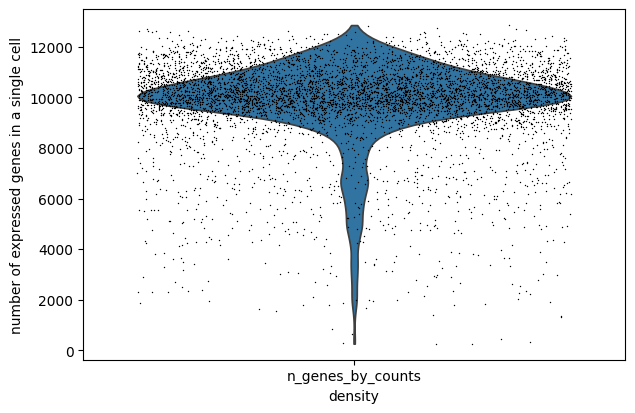

In [105]:
# plot distribution of expressed gene counts per cell
sc.pl.violin(adata, ['n_genes_by_counts'], jitter=0.4, xlabel='density', ylabel='number of expressed genes in a single cell')

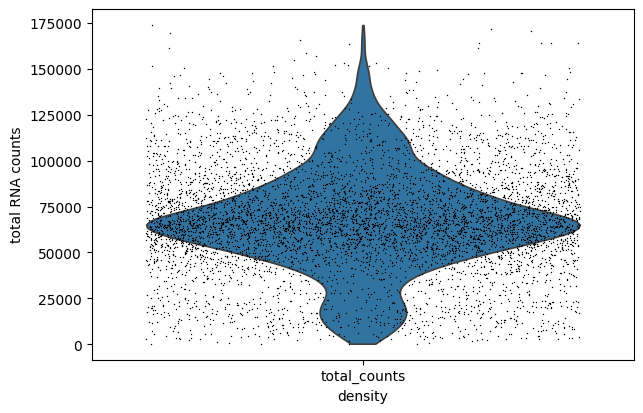

In [106]:
sc.pl.violin(adata, ['total_counts'], jitter=0.4, xlabel='density', ylabel='total RNA counts')

## Normalize & Log-Transform

In [107]:
# normalize gene expression array
sc.pp.normalize_total(adata, target_sum=1e4)

# log-transform data
sc.pp.log1p(adata)

In [108]:
adata.X[0].toarray()

array([[0.08305801, 0.41846624, 0.        , ..., 2.7271857 , 2.0026627 ,
        4.183686  ]], dtype=float32)

# Modeling

## Compute KNN Graph

In [109]:
coordinates = np.array(adata.obs[['x', 'y']])
coordinates

array([[  58.37444881,  509.47806303],
       [ 861.07505454,  359.80265246],
       [1239.26254231,  422.74734282],
       ...,
       [1148.48092618, 1258.42639605],
       [ 390.08050269,  885.89977565],
       [ 342.40457386, 1066.63205489]])

In [110]:
# KNN graph (connect each cell to KNN)
k=6
tree = KDTree(coordinates)
edges = tree.query(coordinates, k=k+1)[1][:, 1:]

In [111]:
# instantiate graph
G = nx.Graph()

# add nodes
for i, (x, y) in enumerate(coordinates):
    G.add_node(i, pos=(x, y))

# add edges
for i, neighbors in enumerate(edges):
    for j in neighbors:
        G.add_edge(i, j)

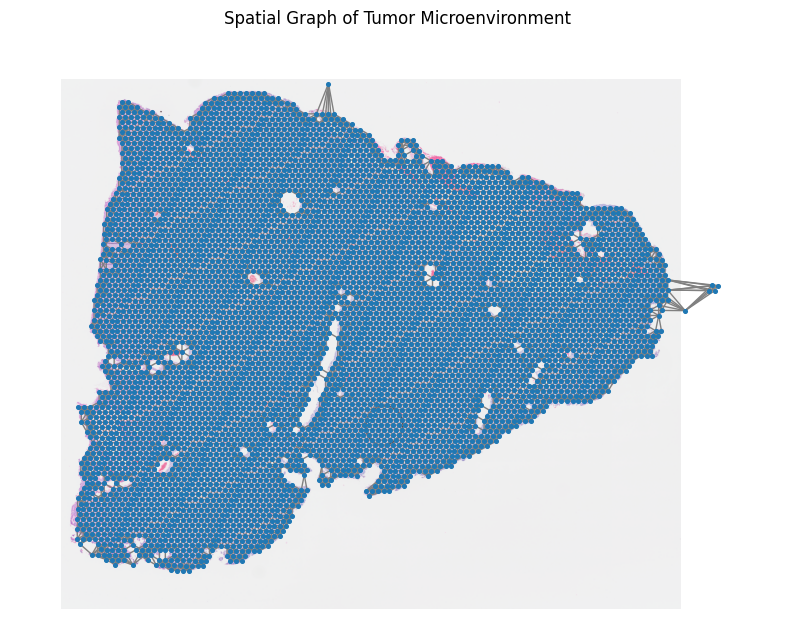

In [112]:
# visualize

# overlay tissue image
plt.figure(figsize=(10, 10))
plt.imshow(tissue_img)

# draw knn graph
nx.draw(G, pos={i: (y, x) for i, (x, y) in enumerate(coordinates)}, edge_color='gray', node_size=7)

plt.title('Spatial Graph of Tumor Microenvironment')
plt.show()

## Train a Graph Neural Network (GNN)

In [113]:
# convert adjacency matrix to pytorch format
edge_index = torch.tensor(list(G.edges), dtype=torch.long).t().contiguous()

# convert gene expression to pytorch tensor
X = torch.tensor(adata.X.toarray(), dtype=torch.float)

# create torch_geometric Data object
data = Data(x=X, edge_index=edge_index)

In [114]:
data

Data(x=[6195, 18085], edge_index=[2, 19119])

In [115]:
# define GNN Model
class GCN(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, output_dim)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

In [116]:
# initialize model
model = GCN(input_dim=X.shape[1],
            hidden_dim=32,
            output_dim=2)

# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# loss
loss_function = torch.nn.CrossEntropyLoss()

In [117]:
# get labels and add to torch_geometric Data object
y = torch.tensor(adata.obs['labels'].values, dtype=torch.long)

data.y = y

In [118]:
# train method
def train(model, data, epochs=50):
    # train mode
    model.train()

    for epoch in range(epochs):
        # reset gradients
        optimizer.zero_grad()

        # forward pass
        out = model(data.x, data.edge_index)

        # calculate loss
        loss = loss_function(out, data.y)

        # backprop
        loss.backward()

        # update weights
        optimizer.step()

        if epoch % 10 == 0:
            print(f'Epoch {epoch} | Loss: {loss.item():.4f}')

In [119]:
# training
train(model, data, epochs=50)

Epoch 0 | Loss: 0.3573
Epoch 10 | Loss: 1.8982
Epoch 20 | Loss: 1.6164
Epoch 30 | Loss: 1.7468
Epoch 40 | Loss: 1.2020


## Evaluate The GCN Model

In [120]:
# evaluation mode
model.eval()

with torch.no_grad():
    # forward pass
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

# store predictions in adata
adata.obs['preds'] = pred.cpu().numpy()

# compute accuracy
acc = (pred == data.y).sum().item() / data.y.size(0)
print(f'GCN Model Accuracy: {acc:.4f}')

GCN Model Accuracy: 0.9845


## Visualize Tumor vs Non-Tumor

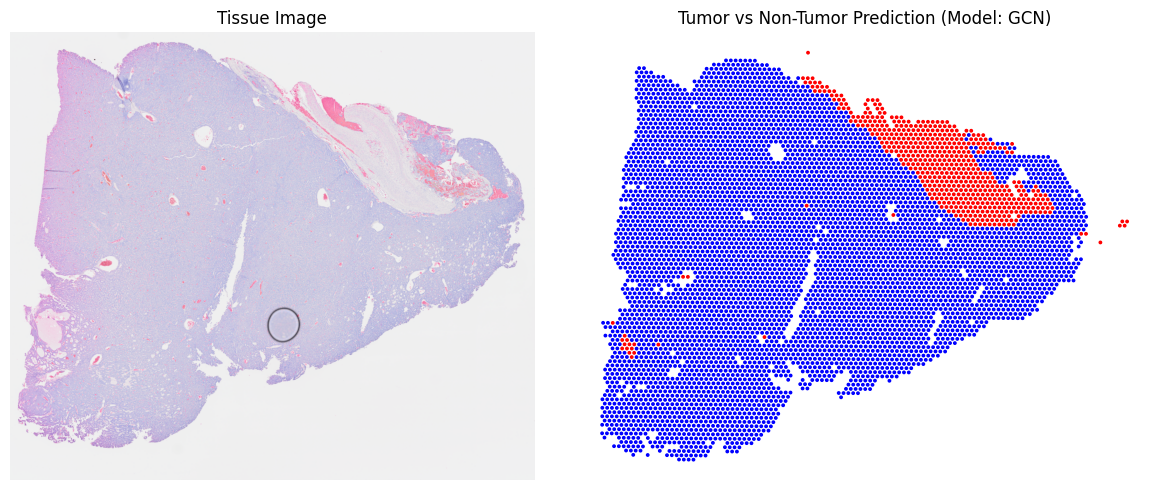

In [132]:
cell_colors = {0: '#0000FF', 1: '#FF0000'}
c = adata.obs['labels'].map(cell_colors)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].imshow(tissue_img)
ax[0].set_title('Tissue Image')
ax[0].axis('off')

scatter = ax[1].scatter(-adata.obs['y'], -adata.obs['x'], s=3, alpha=1, c=c)
ax[1].set_title('Tumor vs Non-Tumor Prediction (Model: GCN)')
ax[1].set_xlabel('x coordinate')
ax[1].set_ylabel('y coordinate')

ax[1].set_xlim(ax[1].get_xlim()[::-1])
ax[1].axis('off')

plt.tight_layout()
plt.show()

# Results

## Metrics

In [122]:
y_true = adata.obs['labels'].values
y_pred = adata.obs['preds'].values

In [123]:
# compute accuracy
acc = accuracy_score(y_true, y_pred)
print(f'Model Accuracy: {acc:.4f}')

Model Accuracy: 0.9845


In [124]:
# classification metrics
print(classification_report(y_true, y_pred, target_names=['Non-Tumor', 'Tumor']))

              precision    recall  f1-score   support

   Non-Tumor       0.99      0.99      0.99      5632
       Tumor       0.90      0.94      0.92       563

    accuracy                           0.98      6195
   macro avg       0.95      0.96      0.95      6195
weighted avg       0.98      0.98      0.98      6195



Through the GCN classification, it allows us to introduce a spatial component in single-cell analysis of lung cancer. By understanding a cell's location in tissue, and its genetic expression profile, we can gain additional insight on how lung cancer develops. 

Traditional ML algorithms i.e. Decision Trees, SVMs, treat each cell independently, not accounting for spatial relationships. GCN incorporate spatial information that models cell-cell interactions via nodes and edges. This allows us to model complex tumor environments: cancer-immune, cancer-fibroblast, cancer-cancer, etc.

Also, pairing our known understanding with the model's predictions helps us evalaluate model perfomance. If effective, we can peredict tumor boundaries more accurately

Single-cell data is sparse, but GCN propogates information across the graph network to improve robustness.

Spatial component allows cells to update their features based on neighbors and neighbors' neighbors. The feature matrix (genetic expression matrix) updates by being multiplied by trainable weights to more accurately represent the cell's label.

Cell's features values now influenced by its neighbors, unlike traditional models.

Cell A: [0.8, 0.1, 0.3]   # High expression of gene 1

Cell B: [0.2, 0.9, 0.4]   # High expression of gene 2

Cell C: [0.6, 0.4, 0.7]   # High expression of gene 3

New Cell A = Mean(Cell A, Cell B, Cell C) * Learnable Weights

Updated Cell A: [0.53, 0.47, 0.47]  # Now incorporates neighbor information
